# Saliency Maps

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pkg.saliency_maps.compute_gradient import run_forecast_with_gradients, run_forecast_with_integrated_gradients

## Run Forecast

In [2]:
# load input data
input = xr.open_dataset(
    "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
).load()

# load climatology
climatology = xr.open_dataset(
    "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"
)


### Vanilla and grad_x_input Gradient

In [ ]:
run_forecast_with_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    upload_to_gcs=False,
)

### Integrated Gradients

In [ ]:
run_forecast_with_integrated_gradients(
    model_name="graphcast_small",
    input_data_or_path=input,
    output_name="zeynep_wind_grad",
    baseline=climatology,
    target_lat=54.0,
    target_lon=9.0,
    lead_hours=6,
    m_steps=20,
    upload_to_gcs=False,
)

## Visualize Results

In [27]:
saliency_path = "data/predictions/zeynep_wind_grad_saliency.nc"
saliency_path_grad_x_input = "data/predictions/zeynep_wind_grad_grad_x_input.nc"

saliency_path_integrated_gradients = "data/predictions/zeynep_wind_grad_intgrad.nc"

input_path = "../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"  

sal_ds = xr.open_dataset(saliency_path)
sal_ds_grad_x_input = xr.open_dataset(saliency_path_grad_x_input)
sal_ds_integrated_gradients = xr.open_dataset(saliency_path_integrated_gradients)

input_ds = xr.open_dataset(input_path)


In [5]:
def plot_atmospheric_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    target_level: float,
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Plot a single‐level atmospheric saliency map over Europe.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'level', 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    target_level : float
        The pressure level (hPa) to slice, e.g. 500.
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    da = sal_ds[f"{varname}_saliency"]
    # find integer index of the nearest level in input_ds
    levels = input_ds["level"].values
    lvl_idx = int(np.argmin(np.abs(levels - target_level)))

    # slice out the 2D field
    da2d = da.isel(batch=batch_index, time=time_index, level=lvl_idx)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )

    # build the figure with Cartopy
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency @ "
            f"{levels[lvl_idx]:.0f} hPa → 10 m Wind"
        )
    ax.set_title(title + f" (t={time_index}, batch={batch_index})")
    plt.tight_layout()
    plt.show()


In [6]:
def plot_aggregated_saliency(
    sal_ds: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    method: str = "mean",
    time_index: int = -1,
    batch_index: int = 0,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r",
    title: str | None = None
):
    """
    Aggregate saliency over all pressure levels and plot the 2D map.

    Parameters
    ----------
    sal_ds : xr.Dataset
        Saliency dataset containing '<varname>_saliency' with dims
        (batch, time, level, lat, lon).
    input_ds : xr.Dataset
        Original input dataset, used for real 'lat', 'lon' coords.
    varname : str
        Base variable name, e.g. "geopotential", "temperature", etc.
    method : str
        Aggregation along the level axis: "mean" or "sum".
    time_index : int
        Which time index to plot (default: -1, the last one).
    batch_index : int
        Which batch index to plot (default: 0).
    extent : list
        [lon_min, lon_max, lat_min, lat_max] for the map extent.
    cmap : str
        Matplotlib colormap.
    title : str or None
        If given, use this as the plot title; otherwise a default is built.
    """
    # pull the saliency
    da = sal_ds[f"{varname}_saliency"]
    
    # aggregate over levels
    if method == "mean":
        da2d = da.mean(dim="level")
    elif method == "sum":
        da2d = da.sum(dim="level")
    else:
        raise ValueError("method must be 'mean' or 'sum'")
    
    # select the desired time & batch slice
    da2d = da2d.isel(batch=batch_index, time=time_index)
    
    # reattach real coords
    da2d = da2d.assign_coords(
        lat=input_ds["lat"],
        lon=input_ds["lon"]
    )
    
    # build the map
    fig, ax = plt.subplots(
        figsize=(10,4),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    vmax = np.abs(da2d).max()
    pcm = da2d.plot.pcolormesh(
        ax=ax, x="lon", y="lat",
        cmap=cmap, vmin=-vmax, vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    agg_label = "Mean" if method=="mean" else "Sum"
    cbar.set_label(f"{agg_label} ∂Wind/∂{varname.replace('_',' ').title()}")
    
    if title is None:
        title = (
            f"{varname.replace('_',' ').title()} Saliency ({agg_label} over levels)"
        )
    ax.set_title(f"{title} – t={time_index}, batch={batch_index}")
    plt.tight_layout()
    plt.show()


In [7]:
def plot_surface_saliency(
    ds_sal: xr.Dataset,
    input_ds: xr.Dataset,
    varname: str,
    time_index: int = -1,
    extent: list = [-25, 45, 30, 75],
    cmap: str = "RdBu_r"
):
    """
    Plot a surface‐only saliency field (no level dim) on a European map.
    
    Parameters
    ----------
    ds_sal : xr.Dataset
      Dataset containing `<varname>_saliency` with dims (batch, time, lat, lon).
    input_ds : xr.Dataset
      Original input, used for lat/lon coords.
    varname : str
      The base variable name, e.g. "2m_temperature" or "mean_sea_level_pressure".
    extent : list
      [lon_min, lon_max, lat_min, lat_max] for map zoom.
    cmap : str
      A matplotlib colormap name.
    """
    da = ds_sal[f"{varname}_saliency"]  # dims: (batch, time, lat, lon)

    # pick batch=0, last time
    da2d = da.isel(batch=0, time=time_index)

    # re‐attach real lat/lon coords
    da2d = da2d.assign_coords(lat=input_ds["lat"], lon=input_ds["lon"])

    # plot
    fig, ax = plt.subplots(
        figsize=(8, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    pcm = da2d.plot.pcolormesh(
        ax=ax,
        x="lon", y="lat",
        cmap=cmap,
        vmin=-np.abs(da2d).max(),
        vmax= np.abs(da2d).max(),
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linestyle=":", linewidth=0.5)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    cbar = fig.colorbar(pcm, ax=ax, orientation="vertical", pad=0.02, aspect=30)
    cbar.set_label(f"∂Wind/∂{varname.replace('_',' ').title()}")

    ax.set_title(f"{varname.replace('_',' ').title()} Saliency → 10 m Wind (22:00 UTC)")
    plt.tight_layout()
    plt.show()



In [ ]:
def plot_field(
    ds,
    time,        
    level,     
    var_name,
    extent=[-25, 45, 30, 75],   
    cmap=None,   
):
    """
    Plot a single field from an xarray Dataset on a PlateCarree map with automatic colormap selection.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset containing atmospheric variables with dimensions (time, level, lat, lon).
    time : int or str
        Time index (integer) or a string matching the time coordinate values.   
    level : float
        Pressure level in hPa (e.g. 850, 500, 300).
    var_name : str
        Variable name to plot (e.g. "u_component_of_wind", "geopotential").
    extent : list, optional
        Map extent as [lon_min, lon_max, lat_min, lat_max].
    cmap : str, optional
        Matplotlib colormap name to use for the plot.
        If None, a default colormap is chosen based on the variable.
    """
    # select the time slice
    try:
        da_time = ds.sel(time=time)
        time_str = str(da_time.time.values)[:16]
    except Exception:
        da_time = ds.isel(time=time)
        time_str = str(ds.time.values[time])[:16]
    # select level
    da_lev = da_time.sel(level=level)

    # Determine data and default colormap
    data = da_lev[var_name]
    # human-readable label
    label = f"{var_name.replace('_',' ').capitalize()} at {level} hPa"
    # choose cmap by variable
    cmap_map = {
        'geopotential': 'coolwarm',
        'temperature': 'RdYlBu_r',
        'specific_humidity': 'PuBu',
        'u_component_of_wind': 'viridis',
        'v_component_of_wind': 'viridis',
        'vertical_velocity': 'seismic'
    }
    default_cmap = cmap_map.get(var_name, 'viridis')

    # final colormap
    use_cmap = cmap if cmap is not None else default_cmap

    # plotting
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    data.plot(
        ax=ax,
        cmap=use_cmap,
        cbar_kwargs={"label": label},
        transform=ccrs.PlateCarree(),
        add_colorbar=True,
        add_labels=False
    )
    ax.set_title(f"{label} — {time_str}")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    plt.tight_layout()
    return fig, ax


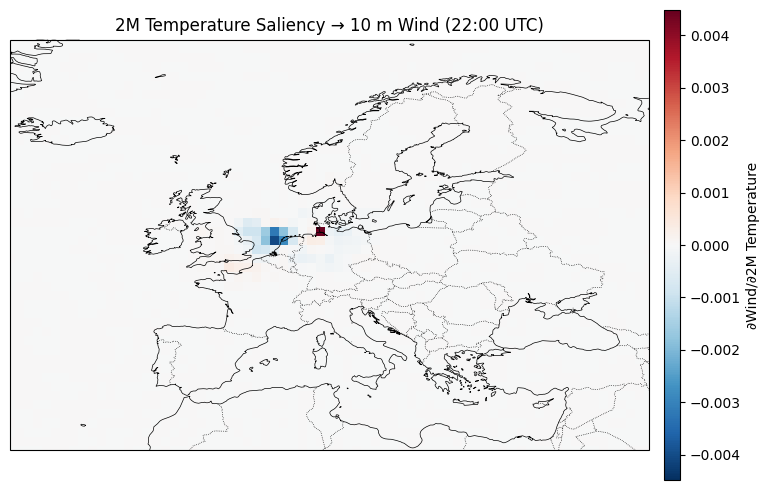

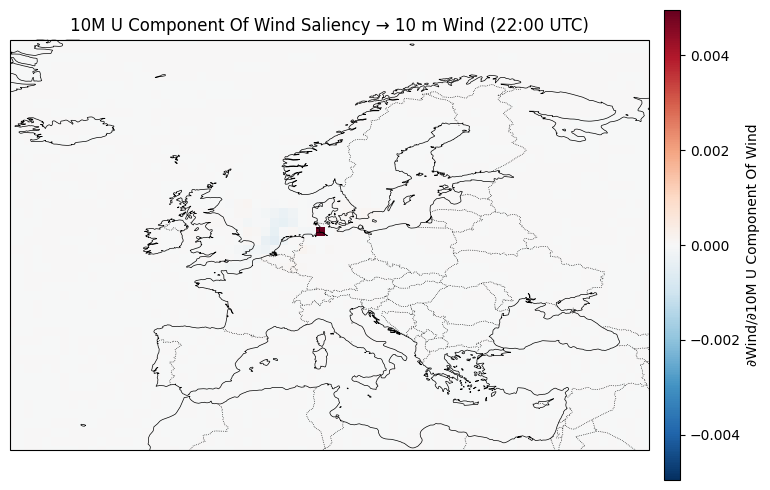

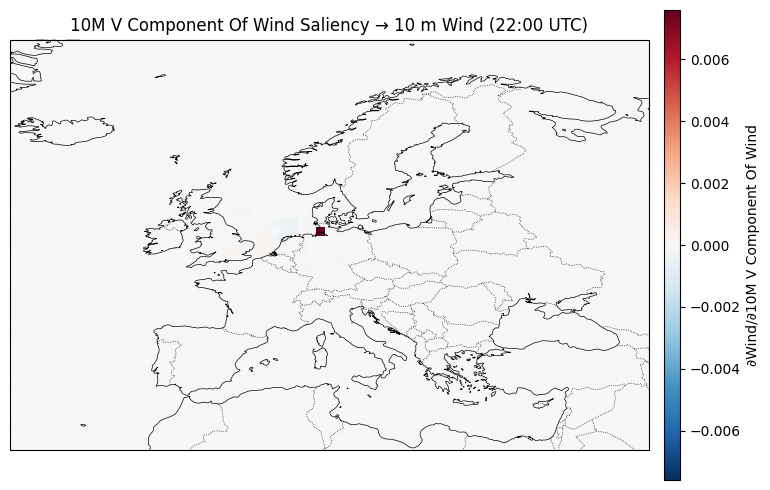

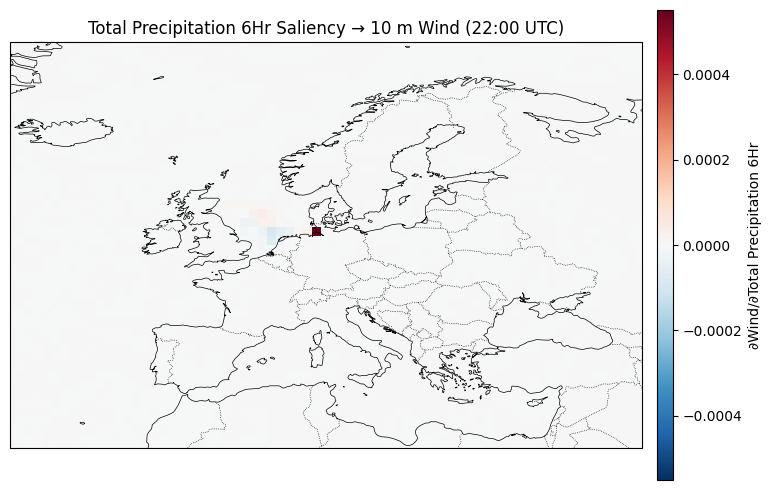

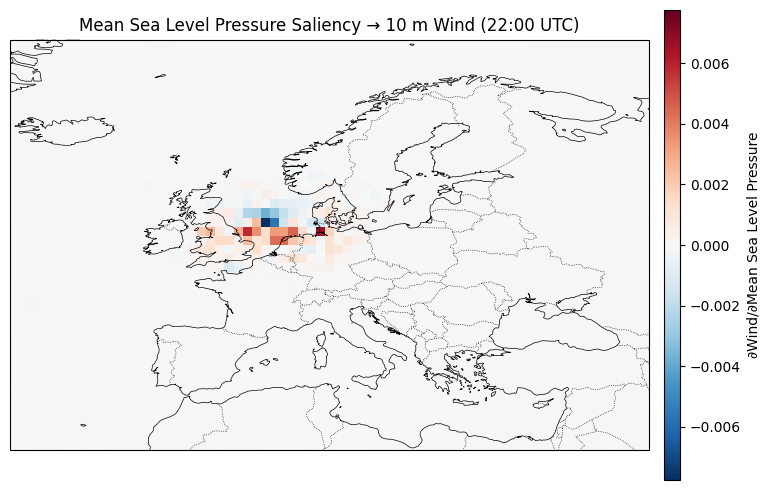

In [51]:
for surf_var in [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_precipitation_6hr",
    "mean_sea_level_pressure"
]:
    plot_surface_saliency(sal_ds_integrated_gradients, input_ds, surf_var, time_index=-2)

Positive values mean increase of input values would also lead to increase of output

Negative values mean that a increase of the input value would lead to a decrease of the output

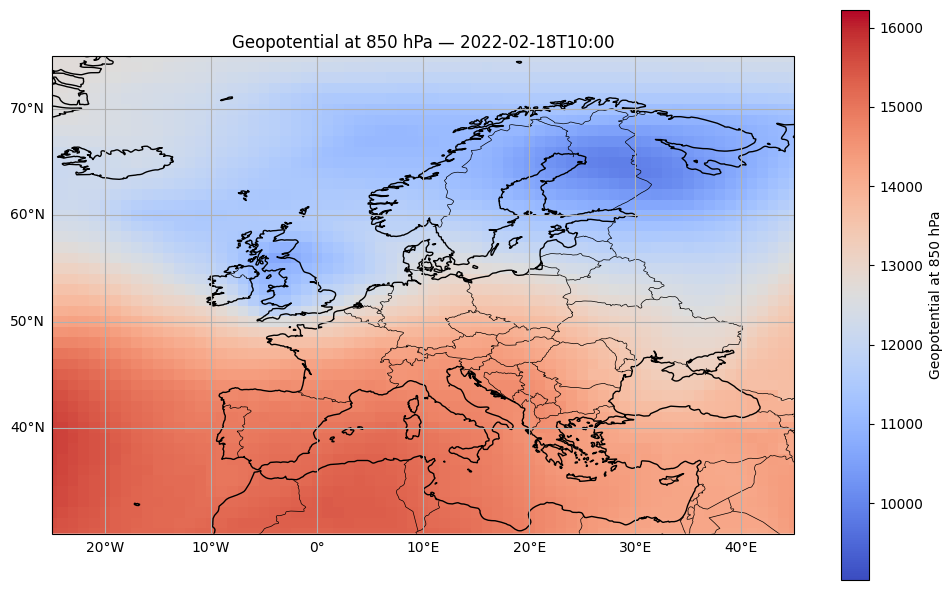

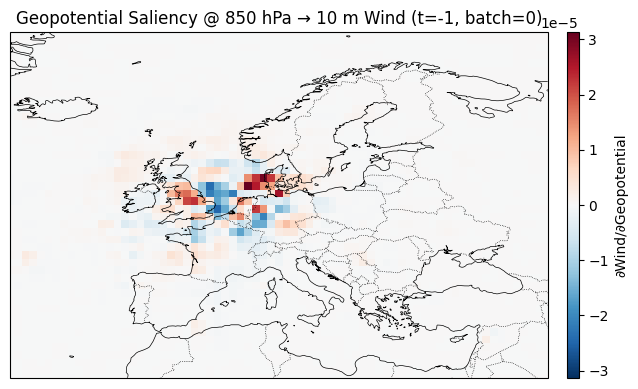

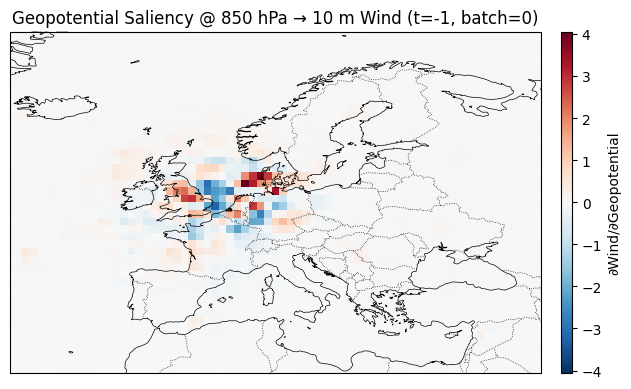

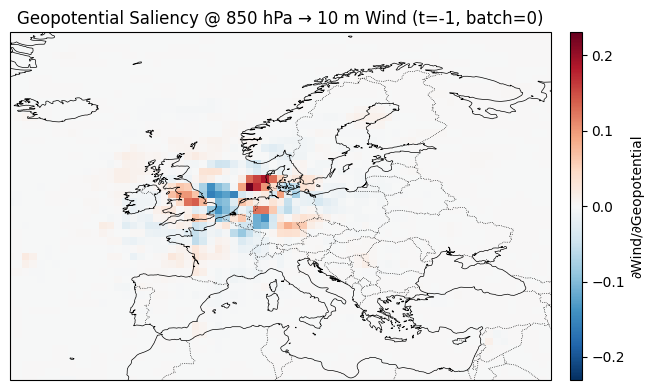

In [50]:
# variables: 
# geopotential, temperature, specific_humidity, 
# u_component_of_wind, v_component_of_wind, vertical_velocity

varname = "geopotential"
level = 850
time = -1
extent=[-25, 45, 30, 75]


plot_field(input_ds, time=0, level=level, var_name=varname, extent=extent)

plot_atmospheric_saliency(
    sal_ds=sal_ds,
    input_ds=input_ds,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent,
    cmap="RdBu_r"
)

plot_atmospheric_saliency(
    sal_ds=sal_ds_grad_x_input,
    input_ds=input_ds,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent,
    cmap="RdBu_r"
)

plot_atmospheric_saliency(
    sal_ds=sal_ds_integrated_gradients,
    input_ds=input_ds,
    varname=varname,
    target_level=level,
    time_index=time,
    batch_index=0,
    extent=extent,
    cmap="RdBu_r"
)